<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/nebula_NGC_1499.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NGC 1499**

[NGC 1499](https://de.m.wikipedia.org/wiki/NGC_1499), also known as the California Nebula, is a large emission nebula located in the constellation Perseus.


![ggg](https://upload.wikimedia.org/wikipedia/commons/thumb/0/05/NGC1499_-_der_Kaliforniennebel.jpg/2560px-NGC1499_-_der_Kaliforniennebel.jpg)

1. **Structure and morphology of nebula**: Analyze shape, filaments, and density variations in the nebula using observational data or images. Process image data from telescopes (e.g., from the Sloan Digital Sky Survey or NASA archives).

2. **Physical conditions of nebula**: Study temperature, density, and ionization conditions. Model emission lines and use spectral data to estimate these properties. Python can be used to model and analyze the emission lines using libraries like `specutils` or `pyspeckit` to fit spectral lines.

3. **Sources of ionization in NGC 1499**: Analyze stars responsible for ionization of hydrogen in nebula. Determine if nearby stars, such as Xi Persei, are significantly contributing to the nebula’s emission. Python could help in analyzing the spectral energy distribution (SED) or luminosity of nearby stars.

4. **Kkinematic behavior of nebula**: Study motion of gas within nebula by analyzing Doppler shifts in spectral lines. Measure and analyze the velocity fields using spectral data.

5. **Star formation activity within NGC 1499**: Investigate if nebula is a region of ongoing star formation by looking for young stellar objects or protostars within the region. Use Python to cross-match catalog data or analyze infrared data (e.g., from the Spitzer Space Telescope) using `astroquery` or `pandas` for star detection.

**Data Collection**

* NGC 1499 (the California Nebula) is primarily a **nebula**, and while SDSS and other astronomical surveys provide extensive spectral data for galaxies, stars, and other compact sources, it's less common for such surveys to provide high-resolution spectra directly for extended emission nebulae like NGC 1499. However, you can still obtain data relevant to NGC 1499 from various sources:

Sources for Spectral Data:
1. **IPHAS (INT Photometric Hα Survey)**: Specialized archive for optical spectral data. Survey covers a region that includes NGC 1499 and focuses on H-alpha emission, which is useful for studying ionized regions like nebulae. The data here can be used to map the emission from the nebula. **For studying H-alpha data specifically, use IPHAS survey since it focuses on H-alpha emissions, which are key in analyzing regions like NGC 1499.**

2. **Spitzer Space Telescope and Herschel**: These space telescopes have data in the infrared, which could provide insights into dust and star-forming regions within NGC 1499.

3. **ESO (European Southern Observatory)**: ESO's archival data can include both optical and infrared spectra of regions near NGC 1499. These spectra might include emission lines useful for studying the nebula. Visit the [ESO Archive Science Portal](http://archive.eso.org/cms.html) to manually search for available spectral data related to NGC 1499.

4. **NASA's Infrared Science Archive (IRSA)**: IRSA contains multiple missions’ worth of data, such as Spitzer and WISE, which could provide photometric and spectroscopic information about NGC 1499.

5. **The Digitized Sky Survey (DSS) and POSS (Palomar Observatory Sky Survey)**: contain optical images that could be processed to extract general spectral information (broadband filters).

6. **Herschel Science Archive:** Specialized archive for optical spectral data. [Herschel Science Archive](https://www.cosmos.esa.int/web/herschel/science-archive)
  


Example: **spectral analysis of emission lines** to determine the physical conditions in NGC 1499. You can use Python libraries to read observational spectral data (e.g., FITS files) and then fit the relevant emission lines (e.g., H-alpha, OIII, SII).

In [3]:
!pip install astroquery -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.9/912.9 kB 46.1 MB/s eta 0:00:00


In [ ]:
# Obtain spectral data for NGC 1499 from an archive like SDSS or another astronomical survey
from astroquery.ipac.irsa import Irsa
from astroquery.sdss import SDSS
from astroquery.vizier import Vizier
import astropy.coordinates as coord
import astropy.units as u

In [5]:
# Check available catalogs
catalogs = Irsa.list_catalogs()
print(catalogs)

{'spitzer.lvl_mips': 'Spitzer LVL MIPS image Metadata', 'spitzer.lvl_irac': 'Spitzer LVL IRAC image Metadata', 'spitzer.lvl_halpha': 'Spitzer LVL HALPHA image Metadata', 'spitzer.lvl_galex': 'Spitzer LVL GALEX image Metadata', 'm31irac': 'M31 IRAC Catalog', 'spitzer.m31irac_image': 'M31IRAC Images', 'mipslg': 'MIPS Local Galaxies Catalog', 'spitzer.mips_lg_images': 'MIPS Local Galaxies (MIPS_LG) Images', 'spitzer.mipsgal_images': 'A 24 and 70 Micron Survey of the Inner Galactic Disk with MIPS (MIPSGAL) Images', 'mipsgala': 'MIPSGAL Archive', 'mipsgalc': 'MIPSGAL Catalog', 'spitzer.s5_spectra': 'S5 Spectra', 'spitzer.s5_lores': 'Spitzer S5 Lo-res', 'spitzer.s5_hires': 'Spitzer S5 Hi-res', 's4gcat': 'S4G Catalog', 's4getg': 'S4G Early Type Galaxy Catalog', 'spitzer.s4g_images': 'The Spitzer Survey of Stellar Structure in Galaxies (S4G) Images', 'spitzer.s4g_details': 'Spitzer S4G Details Metadata', 'safires70': 'SAFIRES MIPS 70 micron Catalog', 'safires160': 'SAFIRES MIPS 160 micron Cata

In [15]:
# Query details about one cataglue
from astroquery.utils.tap.core import Tap

# Define the TAP service URL for IPAC/IRSA
tap_service = Tap(url="https://irsa.ipac.caltech.edu/TAP")

# Perform a TAP query for the catalog metadata (e.g., spitzer.lvl_halpha)
metadata_query = """
SELECT *
FROM TAP_SCHEMA.columns
WHERE table_name = 'spitzer.lvl_halpha'
"""

# Execute the query
metadata_result = tap_service.launch_job(metadata_query)

# Fetch the results as a table
metadata_table = metadata_result.get_results()

# Display the metadata
metadata_table.pprint(max_width=-1)

col_0  col_1        col_2             col_3                                           col_4                                      col_5         col_6         col_7 col_8  col_9 col_10 col_11 col_12 col_13      col_14      col_15 col_16 col_17
----- ------- ------------------ ---------------- ------------------------------------------------------------------------------ ----- --------------------- ----- ------ ----- ------ ------ ------ ------ ---------------- ------ ------ ------
    1 spitzer spitzer.lvl_halpha             cntr                               entry counter (key) number (unique within table)       meta.record;meta.main          int     1      1      1      0      0             cntr           11d       
    2 spitzer spitzer.lvl_halpha               ra                               Right Ascension of image center (degrees, J2000)         pos.eq.ra;meta.main       double     1      1      1      0      0               ra         12.6f       
    3 spitzer spitzer.lvl_halpha

In [16]:
# Coordinates for NGC 1499 (California Nebula)
california_nebula_coords = coord.SkyCoord('04h03m14.0s +36d25m19s', frame='icrs')

# Query IRSA data from the spitzer.lvl_halpha catalog (IRAC/MIPS observations)
spitzer_halpha_data = Irsa.query_region(california_nebula_coords, catalog='spitzer.lvl_halpha', spatial='Cone', radius=30*u.arcmin)

# Display the retrieved data
print(spitzer_halpha_data)

cntr  ra dec cra cdec naxis1 naxis2 ... band_name wavelength access_estsize s_fov tile  pt poly
---- --- --- --- ---- ------ ------ ... --------- ---------- -------------- ----- ---- --- ----


In [22]:
# Display the available columns
print(spitzer_halpha_data.colnames)

['cntr', 'ra', 'dec', 'cra', 'cdec', 'naxis1', 'naxis2', 'ctype1', 'ctype2', 'crpix1', 'crpix2', 'crval1', 'crval2', 'cdelt1', 'cdelt2', 'crota2', 'equinox', 'ra1', 'dec1', 'ra2', 'dec2', 'ra3', 'dec3', 'ra4', 'dec4', 'size', 'hdu', 'fname', 'facility_name', 'instrument_name', 'dataproduct_type', 'file_type', 'band_name', 'wavelength', 'access_estsize', 's_fov', 'tile', 'pt', 'poly']


In [17]:
# Check the first few rows to understand the format
print(spitzer_halpha_data[:5])

# Display column names and data types
print(spitzer_halpha_data.colnames)

cntr  ra dec cra cdec naxis1 naxis2 ... band_name wavelength access_estsize s_fov tile  pt poly
---- --- --- --- ---- ------ ------ ... --------- ---------- -------------- ----- ---- --- ----
['cntr', 'ra', 'dec', 'cra', 'cdec', 'naxis1', 'naxis2', 'ctype1', 'ctype2', 'crpix1', 'crpix2', 'crval1', 'crval2', 'cdelt1', 'cdelt2', 'crota2', 'equinox', 'ra1', 'dec1', 'ra2', 'dec2', 'ra3', 'dec3', 'ra4', 'dec4', 'size', 'hdu', 'fname', 'facility_name', 'instrument_name', 'dataproduct_type', 'file_type', 'band_name', 'wavelength', 'access_estsize', 's_fov', 'tile', 'pt', 'poly']


In [19]:
# Download the image using the access URL (file name)
for row in spitzer_halpha_data:
    print(row['fname'])  # This will print the file names for images associated with NGC 1499

Filename: /root/.astropy/cache/download/url/02780f6eddae504459a02d31d1ef7da5/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     262   (200, 200, 4)   float32   
  1  u5780205r_cvt.c0h.tab    1 TableHDU       353   4R x 49C   [D25.17, D25.17, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, A1, E15.7, I12, I12, D25.17, D25.17, A8, A8, I12, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, I12, I12, I12, I12, I12, I12, I12, I12, A48, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7, E15.7]   
Image data shape: (4, 200, 200)


TypeError: Invalid shape (4, 200, 200) for image data

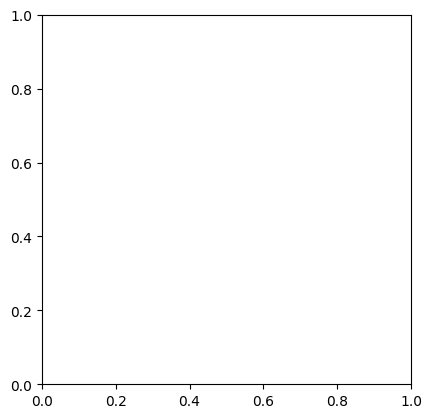

In [23]:
# Opening and Analyzing FITS Images with astropy.io.fits:
import astropy.io.fits as fits
import matplotlib.pyplot as plt

# Replace 'path_to_fits_file' with the path to your downloaded FITS file
fits_file = 'https://fits.gsfc.nasa.gov/samples/WFPC2u5780205r_c0fx.fits'

# Open the FITS file
with fits.open(fits_file) as hdul:
    # Print the FITS file structure
    hdul.info()

    # Access the image data (usually in the primary HDU or the first HDU)
    image_data = hdul[0].data  # For some files it might be hdul[1].data depending on the structure

# Check the dimensions of the image data
print(f"Image data shape: {image_data.shape}")

# Plot the image using matplotlib
plt.imshow(image_data, cmap='gray', origin='lower')
plt.colorbar(label='Pixel value')
plt.title('FITS Image')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()

In [ ]:
# Visualizing FITS Images with aplpy:
import aplpy

# Create a figure to display the image
fig = aplpy.FITSFigure(fits_file)

# Display the image data
fig.show_grayscale(stretch='log')  # You can choose 'linear', 'log', etc. for contrast stretching

# Add grid, axis labels, and a color bar
fig.add_grid()
fig.grid.set_color('white')
fig.grid.set_alpha(0.3)

# Add a color bar to visualize the range of pixel values
fig.add_colorbar()
fig.colorbar.set_axis_label_text('Pixel Value')

# Add axis labels in RA/Dec
fig.axis_labels.show()
fig.axis_labels.set_xtext('RA')
fig.axis_labels.set_ytext('Dec')

# Show the plot
fig.show()


### Analyse spectral properties

In [18]:
# Read the data using astropy or specutils:
from astropy.io import fits
from astropy.visualization import quantity_support
import matplotlib.pyplot as plt

# Load the FITS file
with fits.open(spitzer_data) as hdul:
    hdul.info()
    # Extract the spectral data
    spectral_data = hdul[1].data

# Plot the spectrum
plt.plot(spectral_data['wavelength'], spectral_data['flux'])
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux (erg/s/cm^2/Angstrom)')
plt.show()

ValueError: Empty filename: <Table length=0>
 cntr    ra     dec    cra    cdec  naxis1 ... wavelength access_estsize  s_fov   tile   pt    poly 
int32 float64 float64 object object int32  ...  float64       int32      float64 int32 object object
----- ------- ------- ------ ------ ------ ... ---------- -------------- ------- ----- ------ ------

In [ ]:
# Fit the emission lines to estimate nebular properties (e.g., temperature, density):
from specutils import Spectrum1D
from specutils.fitting import fit_lines
from astropy.modeling import models

# Create a Spectrum1D object
spectrum = Spectrum1D(spectral_axis=spectral_data['wavelength'], flux=spectral_data['flux'])

# Fit a Gaussian to the H-alpha emission line
gaussian_model = models.Gaussian1D(amplitude=1, mean=6563, stddev=1)
fitted_gaussian = fit_lines(spectrum, gaussian_model)

Further Analysis: Once the emission lines are fitted, one can calculate physical parameters like electron density, temperature, or even the ionization state of the gas using theoretical models.